<a href="https://colab.research.google.com/github/1021114Carlos/MIT_MM_Finance/blob/Finance-shop/Courses/Mathematical_Methods_Quantitative_Finance/M2_Discrete%20time%20stochastic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
from scipy import stats

Lecture Code

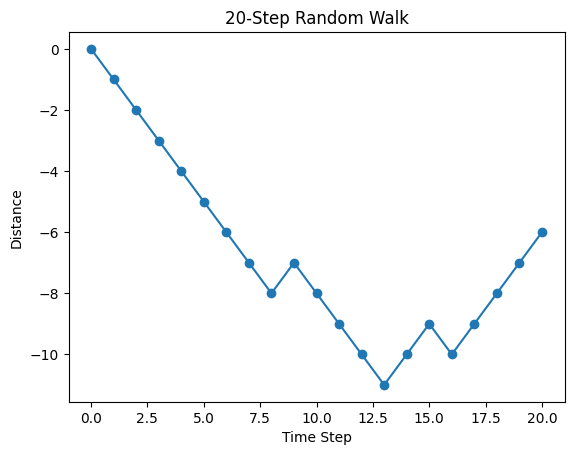

In [ ]:
p = 0.5
nt = 20
n_paths = 1

rng = np.random.default_rng()               # Generate random draws and transform to +1 or -1
z = rng.random(nt)
x = np.where(z < p, 1, -1)

# Initialize the walk (starts at 0)
s = np.zeros(nt + 1)

# for t in range(nt):
#     s[t+1] = s[t] + x[t]
s = np.concatenate([[0], np.cumsum(x)])

# Plotting
plt.plot(s, '-o')                           # '-o' gives the line + dots
plt.title("20-Step Random Walk")
plt.xlabel("Time Step")
plt.ylabel("Distance")
plt.show()


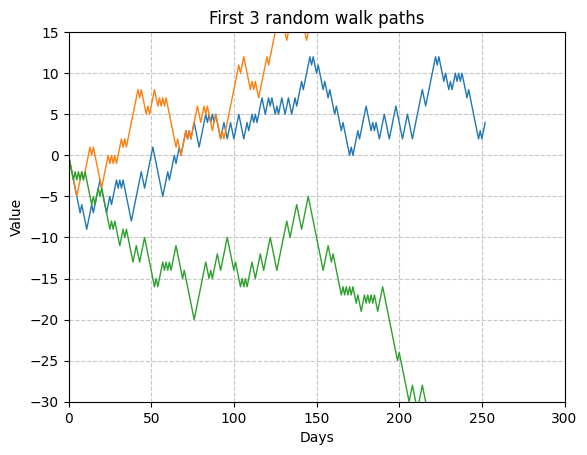

In [ ]:
# Many simulations of a one-year daily walk

p = 0.5
nt = 252
n_paths = 10000  # 1e4 converted to integer
rng = np.random.default_rng()
z = rng.random((nt, n_paths))

x = np.where(z < p, 1, -1)
s = np.zeros((nt +1, n_paths))
s[1:, :] = np.cumsum(x, axis=0)

plt.plot(s[:, 0:3], linewidth=1)
plt.title("First 3 random walk paths")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xlim(0, 300)
plt.ylim(-30, 15)
plt.xlabel("Days")
plt.ylabel("Value")
plt.show()

Recitation

In [ ]:
from google.colab import files

In [ ]:
uploaded = files.upload()

Saving assetWeek2MIT.csv to assetWeek2MIT.csv


In [ ]:
plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

tr = pd.read_csv("assetWeek2MIT.csv", parse_dates=['date'])
tr = tr.set_index('date').sort_index()

In [ ]:
print(f"loaded {len(tr)} rows | {tr.index[0].date()} -> {tr.index[-1].date()}")
print(tr.head());


loaded 7562 rows | 1987-12-31 -> 2017-12-29
           symbol      open      high       low     close  volume  adjusted
date                                                                       
1987-12-31     TR  4.083359  4.256382  4.083359  4.256382   25286  2.755930
1988-01-04     TR  4.256382  4.394801  4.221778  4.290987   40457  2.778338
1988-01-05     TR  4.360197  4.637034  4.360197  4.464011  114146  2.890368
1988-01-06     TR  4.533220  4.550523  4.360197  4.515918   60685  2.923977
1988-01-07     TR  4.498616  5.069594  4.498616  5.017687  103310  3.248863


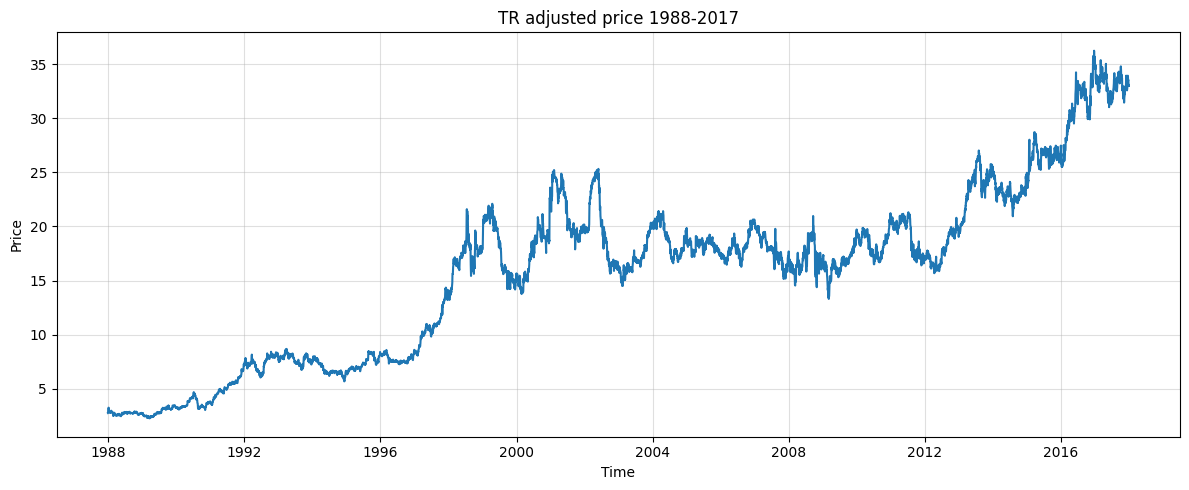

In [ ]:
# Price chart
plt.figure()
plt.plot(tr.index, tr["adjusted"])
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('TR adjusted price 1988-2017')
plt.tight_layout()
plt.show()


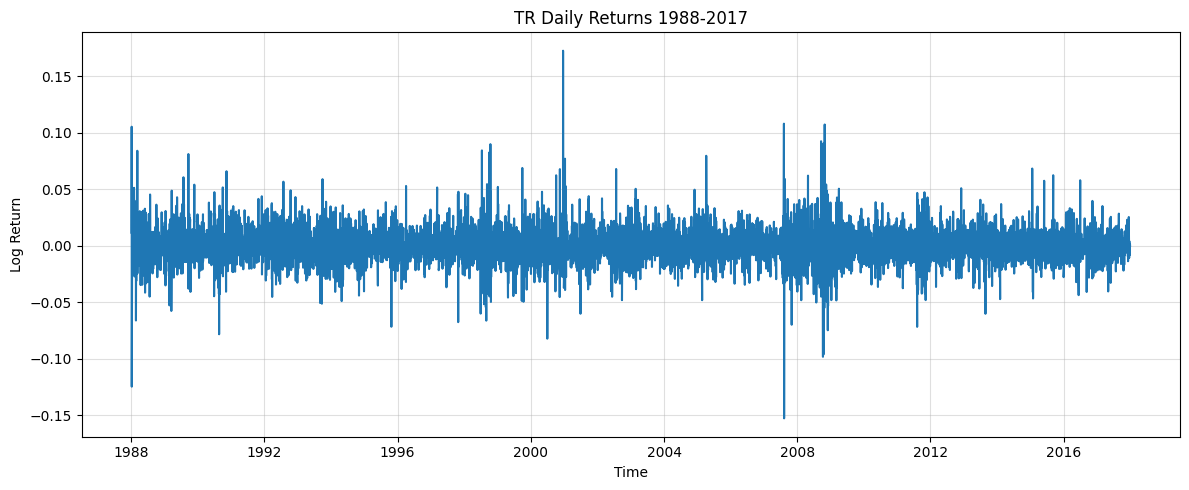

In [ ]:
p = tr['adjusted'].values
r = np.diff(np.log(p))
N = len(r)

tr['r'] = np.concatenate([[np.nan], r])

tr = tr.iloc[1:]   # drop first Nan row

plt.figure()
plt.plot(tr.index, tr['r'])
plt.xlabel('Time')
plt.ylabel('Log Return')
plt.title('TR Daily Returns 1988-2017')
plt.tight_layout()
plt.show()

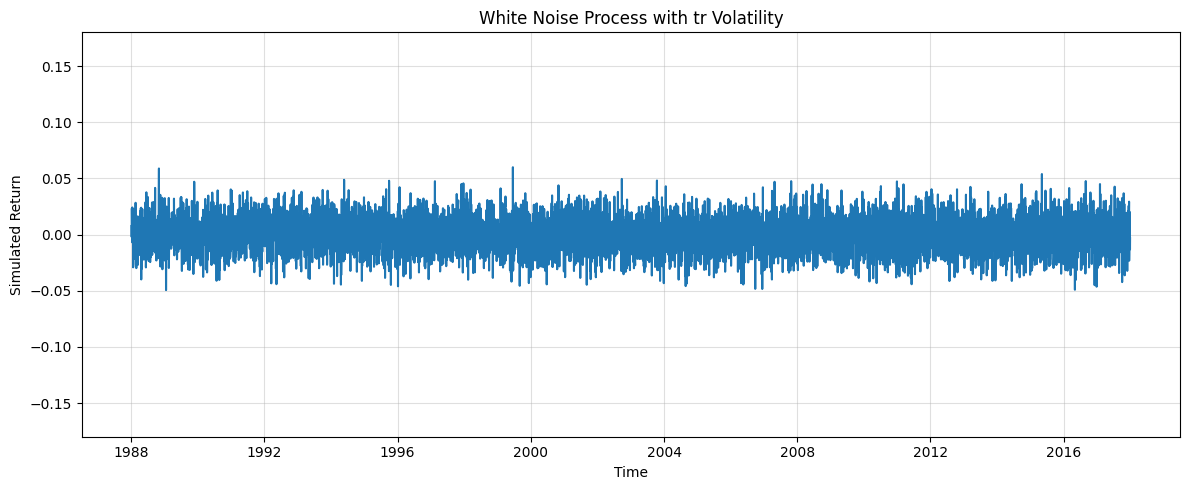

In [ ]:
# White noise comparison
# Simulated returns with the same average volatility and zero mean

np.random.seed(42)
white_noise = np.random.randn(len(tr))*np.std(tr['r'])

plt.figure()
plt.plot(tr.index, white_noise)
plt.ylim(-0.18, 0.18)
plt.xlabel('Time')
plt.ylabel('Simulated Return')
plt.title('White Noise Process with tr Volatility')
plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics

print(tr.describe())

              open         high          low        close        volume  \
count  7560.000000  7560.000000  7560.000000  7560.000000  7.560000e+03   
mean     18.717586    18.896698    18.532738    18.720668  1.000711e+05   
std       8.338280     8.418284     8.250234     8.337196  1.253311e+05   
min       3.495078     3.529683     3.460473     3.460473  0.000000e+00   
25%      10.381420    10.502537    10.312211    10.381420  3.973400e+04   
50%      20.613025    20.816683    20.356454    20.604664  7.560100e+04   
75%      24.075791    24.325567    23.873047    24.108770  1.256982e+05   
max      37.703835    38.115650    37.292023    38.024136  6.359452e+06   

          adjusted            r  
count  7560.000000  7560.000000  
mean     15.740270     0.000327  
std       7.984123     0.015262  
min       2.262289    -0.152747  
25%       7.790487    -0.007796  
50%      17.123010     0.000000  
75%      19.951747     0.008097  
max      36.243126     0.172633  


In [ ]:
# Annualization (252 trading days/year)
ann_return = np.mean(r)*252
ann_vol = np.std(r, ddof=1)*np.sqrt(252)

print(f"Mean return: {ann_return:.4f} ({ann_return*100:.2f}%)")
print(f"Volatility: {ann_vol:.4f} ({ann_vol*100:.2f}%)")
print()
print(pd.Series(r, name="daily log return").describe())

Mean return: 0.0825 (8.25%)
Volatility: 0.2423 (24.23%)

count    7560.000000
mean        0.000327
std         0.015262
min        -0.152747
25%        -0.007796
50%         0.000000
75%         0.008097
max         0.172633
Name: daily log return, dtype: float64


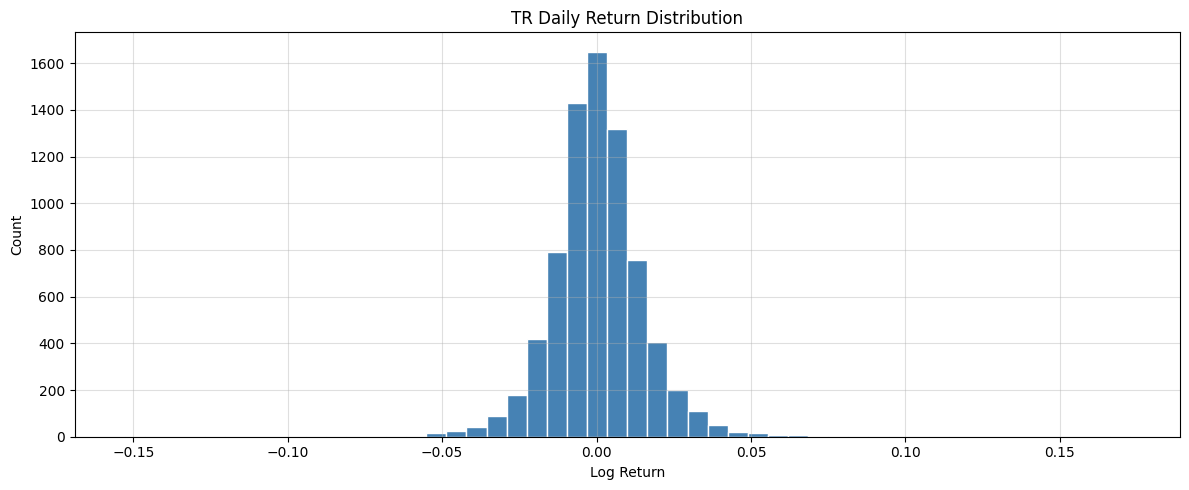

In [ ]:
# Return distribution

plt.figure()
plt.hist(r, bins=50, edgecolor='white', color='steelblue')
plt.xlabel('Log Return')
plt.ylabel('Count')
plt.title('TR Daily Return Distribution')
plt.tight_layout()
plt.show()

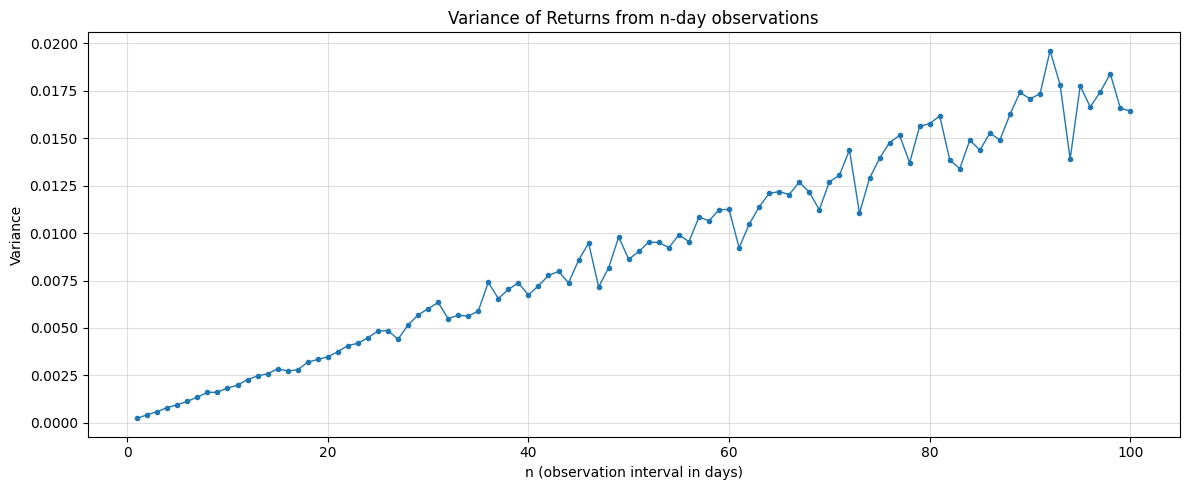

In [ ]:
# Lo & MacKinlay - Variance plot
# Under a random walk, var(n-day return ) should grow linearly with n

log_p = np.log(p)
variance = np.zeros(100)

for n in range(1, 101):
  sub = log_p[n-1::n]
  variance[n-1] = np.var(np.diff(sub), ddof=1)

plt.figure()
plt.plot(range(1, 101), variance, marker='o', markersize=3, linewidth=1)
plt.xlabel('n (observation interval in days)')
plt.ylabel('Variance')
plt.title('Variance of Returns from n-day observations')
plt.tight_layout()
plt.show()


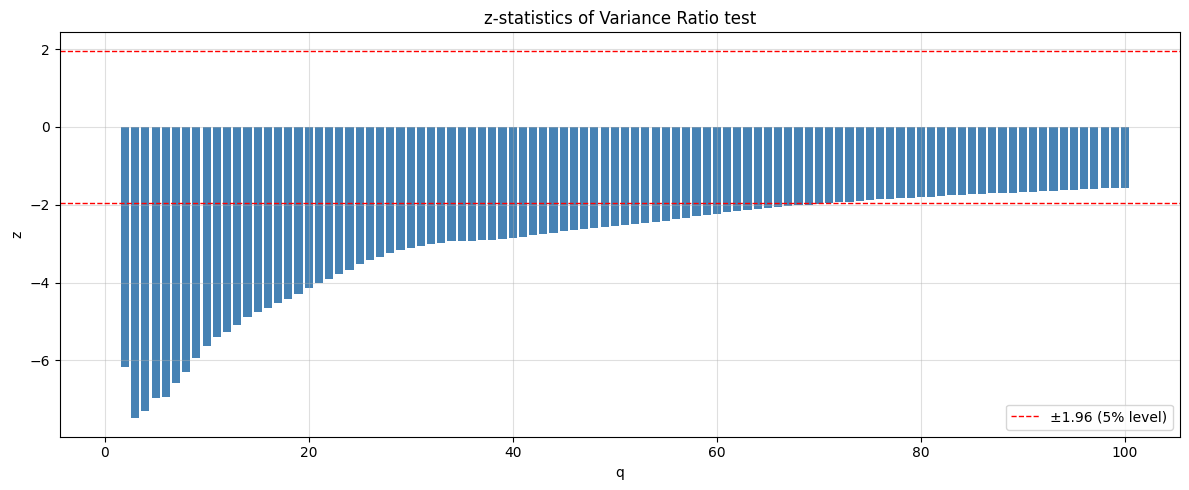

In [ ]:
# Variance ratio functions (Lo & MacKinlay 1988)

def variance_c(x, q):
  """
    Overlapping q-period variance estimator.
  """
  t = len(x) -1
  mu = (x[t]-x[0])/t
  m = (t-q)*(t-q+1)*q/t
  sumsq = sum((x[t+1]-x[t-q+1]-q*mu)**2
              for t in range(q-1, t))
  return sumsq/m

def z_stat(x, q):
  """
  z-statistic for the variance ratio test.
  Asymptotically N(0, 1) under the random walk null.
  """
  t = len(x) - 1
  c = np.sqrt(t*(3*q)/(2*(2*q-1)*(q-1)))
  m = variance_c(x,q)/variance_c(x,1)-1
  return c*m

# z-statistics bar chart

vc = np.array([variance_c(log_p, q) for q in range(1, 101)])
zstats = np.array([0.0]+[z_stat(log_p, q) for q in range(2, 101)])
p_values = 2*stats.norm.sf(np.abs(zstats))

plt.figure()
plt.bar(range(1, 101), zstats, color='steelblue', edgecolor='none')
plt.axhline(1.96, color='red', linestyle='--', linewidth=1, label='±1.96 (5% level)')
plt.axhline(-1.96, color='red', linestyle='--', linewidth=1)
plt.xlabel('q')
plt.ylabel('z')
plt.title('z-statistics of Variance Ratio test')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
for q in [2, 5, 10, 20, 50]:
  print(f"q={q:>2d} z={zstats[q-1]:+.3f} p={p_values[q-1]:.4f}")


q= 2 z=-6.179 p=0.0000
q= 5 z=-6.959 p=0.0000
q=10 z=-5.634 p=0.0000
q=20 z=-4.144 p=0.0000
q=50 z=-2.537 p=0.0112


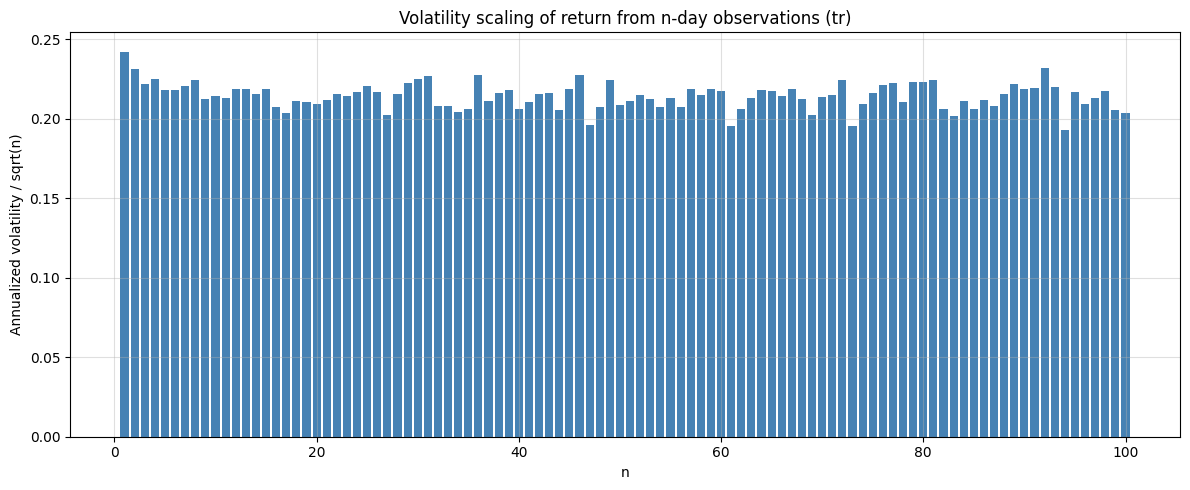

In [ ]:
# Scale volatility - empirical
# under IID returns, annualized vol should be flat across all horizons.
sigma = np.zeros(100)
for n in range(1, 101):
  sub = log_p[n-1::n]
  sigma[n-1] = np.sqrt(252/n)*np.std(np.diff(sub), ddof=1)

plt.figure()
plt.bar(range(1, 101), sigma, color='steelblue', edgecolor='none')
plt.xlabel('n')
plt.ylabel("Annualized volatility / sqrt(n)")
plt.title('Volatility scaling of return from n-day observations (tr)')
plt.tight_layout()
plt.show()

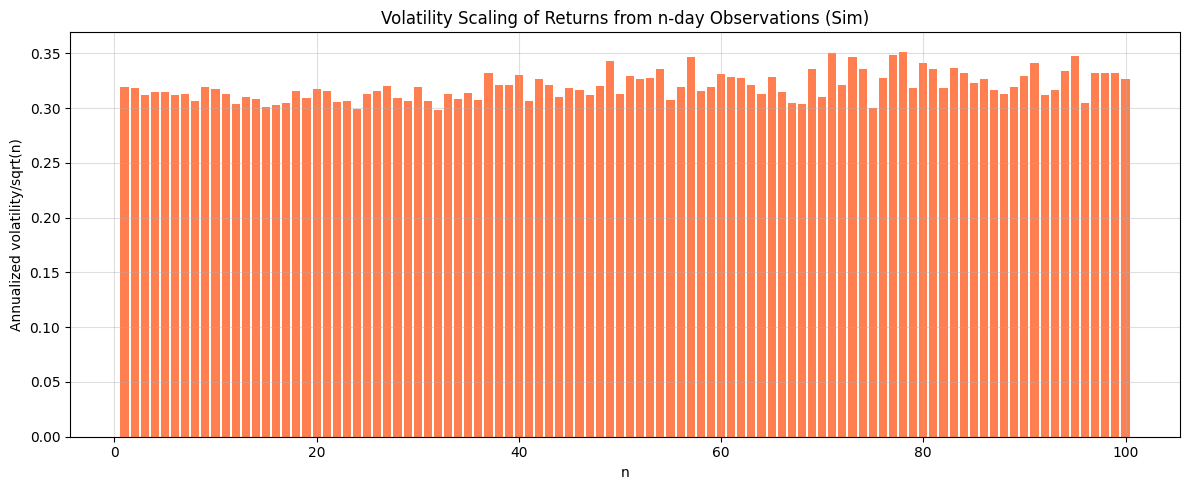

In [ ]:
# Scale Volatility - Monte Carlo Simulation
# Simulate a pure random wak (~32% annual vol) as a benchmark.
# A true random walk produces a flat bar chart

np.random.seed(42)
p_mc = np.exp(np.cumsum(np.random.randn(N)*0.02))
logP_mc = np.log(p_mc)

sigma_mc = np.zeros(100)

for n in range(1, 101):
  sub = logP_mc[n-1::n]
  if len(sub)>1:
    sigma_mc[n-1] = np.sqrt(252/n)*np.std(np.diff(sub), ddof=1)

plt.figure()
plt.bar(range(1, 101), sigma_mc, color='coral', edgecolor='none')
plt.xlabel('n')
plt.ylabel('Annualized volatility/sqrt(n)')
plt.title('Volatility Scaling of Returns from n-day Observations (Sim)')
plt.tight_layout()
plt.show()

Assigment: Time Series

Q1 (a):